run 
```
ti cache clean
python MLUPS_test.py > log_file_name.log
```

In this notebook you can analyse the log file. 

In [40]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [41]:
def real_time_threshold(nLattice,dt):
    return nLattice/dt/1e6

In [42]:
def parse_log_v1(log_file):
    n_lattice_list = []
    macro_MLUPS_list = [] # 总计算量/总时间
    init_time_list = []
    compile_time_list = []
    avg_MLUPS_list = [] # 每次计算量/每次时间 mean
    std_MLUPS_list = [] # 每次计算量/每次时间 std
    with open(log_file, 'r',encoding='utf-8') as f:
        line = f.readline() # 第一行忽略
        line = f.readline()
        while line: 
            line2 = f.readline() # n lattice
            line3 = f.readline() # MLUPS
            line4 = f.readline() # avg time
            line5 = f.readline() # compile time
            line6 = f.readline() # init time
            line7 = f.readline() # v test
            line8 = f.readline() # execution time list
            line9 = f.readline() # -----
            line = f.readline() # EOF or next arch
            nLattice = int(line2)
            n_lattice_list.append(nLattice)
            macro_MLUPS_list.append(float(line3))
            compile_time_list.append(float(line5))
            init_time_list.append(float(line6))
            exec_time_list = [float(t) for t in line8[1:-2].split(',') if t.strip()!='']
            exec_time_array = np.array(exec_time_list)
            MLUPS_array = nLattice*10000 / (exec_time_array * 1e6)
            avg_MLUPS_list.append(np.mean(MLUPS_array))
            std_MLUPS_list.append(np.std(MLUPS_array))
    return n_lattice_list, avg_MLUPS_list, std_MLUPS_list, compile_time_list, init_time_list

In [43]:
def parse_log_v2(log_file):
    n_lattice_list = []
    avg_MLUPS_list = []
    std_MLUPS_list = []
    init_time_list = []
    compile_time_list = []
    with open(log_file, 'r') as f:
        line = f.readline() # 第一行忽略
        line = f.readline()
        while line: 
            line2 = f.readline() # n lattice
            line3 = f.readline() # avg MLUPS
            line4 = f.readline() # std MLUPS
            line5 = f.readline() # compile time
            line6 = f.readline() # init time
            line8 = f.readline() # execution time list
            line9 = f.readline() # -----
            line = f.readline() # EOF or next arch
            try:
                nLattice = int(line2.split(":")[1].strip())
                n_lattice_list.append(nLattice)
                compile_time_list.append(float(line5.split(":")[1].strip()))
                init_time_list.append(float(line6.split(":")[1].strip()))
                # exec_time_list = [float(t) for t in line8.split(':')[1] if t.strip()!='']
                avg_MLUPS_list.append(float(line3.split(":")[1].strip()))
                std_MLUPS_list.append(float(line4.split(":")[1].strip()))
            except: # invalid ending due to interruption
                pass
    return n_lattice_list, avg_MLUPS_list, std_MLUPS_list, compile_time_list, init_time_list

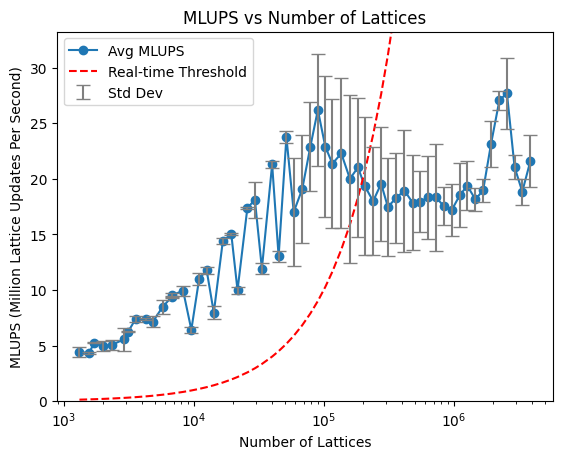

In [ ]:
log_file = "laptop_cpu_MLUPS.log" # log file path
n_lattice_list,  avg_MLUPS_list, std_MLUPS_list, compile_time_list, init_time_list = parse_log_v1(log_file)
MLUPS_threshold_list = [real_time_threshold(nLattice,dt=0.01) for nLattice in n_lattice_list]
plt.plot(n_lattice_list, avg_MLUPS_list, 'o-', label='Avg MLUPS')
plt.errorbar(n_lattice_list, avg_MLUPS_list, yerr=std_MLUPS_list, fmt='none', ecolor='gray', capsize=5, label='Std Dev')
plt.plot(n_lattice_list, MLUPS_threshold_list, 'r--', label='Real-time Threshold')
plt.ylim(0, max(avg_MLUPS_list)*1.2)
plt.xscale('log')
plt.xlabel('Number of Lattices')
plt.ylabel('MLUPS (Million Lattice Updates Per Second)')
plt.title('MLUPS vs Number of Lattices')
plt.legend()
plt.show()

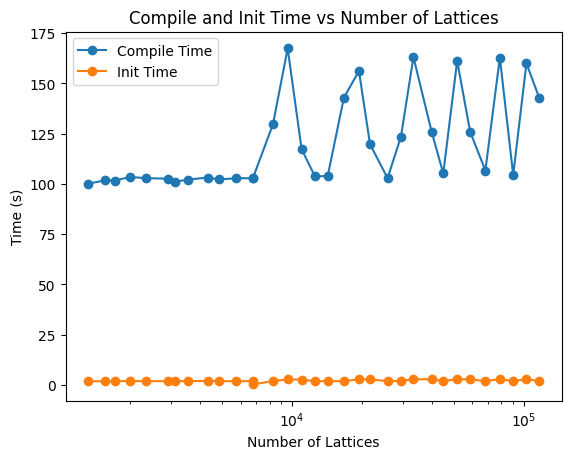

In [45]:
plt.plot(n_lattice_list, compile_time_list, 'o-', label='Compile Time')
plt.plot(n_lattice_list, init_time_list, 'o-', label='Init Time')
plt.xlabel('Number of Lattices')
plt.ylabel('Time (s)')
plt.title('Compile and Init Time vs Number of Lattices')
plt.legend()
plt.xscale('log')
plt.show()